# 기준금리 변화와 가계대출 연체율 간 시차 관계 분석

**분석 목적**: 한국은행 기준금리와 가계대출 연체율 사이의 시차 관계를 시계열 분석을 통해 탐색

**가설**: 기준금리 변화와 이후 가계대출 연체율 변화 사이에 일정한 시차를 둔 양의 상관관계가 나타날 것이다.

**데이터 출처**: 한국은행 경제통계시스템(ECOS), 월별 데이터
- 한국은행 기준금리 (2019.01 ~ 2025.12)
- 예금은행 가계대출 연체율(전체1M, 전국, 국내은행) (2019.12 ~ 2025.12)
- 공통 분석 기간: 2019.12 ~ 2025.12, 총 73개월

**분석 순서**
1. 데이터 전처리
2. 기본/구간별 시각화
3. 원시계열 시차 상관관계 분석
4. 정책 구간별 평균 연체율 비교
5. 차분 + ADF 정상성 검정
6. 차분 데이터 CCF 분석 (statsmodels) 

## 1. 데이터 불러오기 & 전처리

In [2]:
# =====================
# 라이브러리 불러오기
# pandas: 데이터 처리 도구
# numpy: 수치 계산 및 신뢰한계 계산
# matplotlib: 그래프 시각화 도구
# =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (윈도우 기본 폰트)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
# =====================
# 데이터 불러오기
# ECOS에서 다운받은 CSV 파일 두 개를 불러옴
# =====================
df_rate = pd.read_csv('base_rate.csv')
df_delinq = pd.read_csv('delinquency_rate.csv')

print(df_rate.head())
print(df_delinq.head())

                        통계표       계정항목  단위   변환  2019/01  2019/02  2019/03  \
0  1.3.1. 한국은행 기준금리 및 여수신금리  한국은행 기준금리  연%  원자료     1.75     1.75     1.75   

   2019/04  2019/05  2019/06  ...  2025/03  2025/04  2025/05  2025/06  \
0     1.75     1.75     1.75  ...     2.75     2.75      2.5      2.5   

   2025/07  2025/08  2025/09  2025/10  2025/11  2025/12  
0      2.5      2.5      2.5      2.5      2.5      2.5  

[1 rows x 88 columns]
                     통계표              계정항목 지역코드            보고기관 단위   변환  \
0  1.2.3.7. 예금은행 지역별 연체율    가계대출 연체율(전체1M)   전국  국내은행(수출입은행 포함)  %  원자료   

   2019/12  2020/01  2020/02  2020/03  ...  2025/03  2025/04  2025/05  \
0     0.26     0.29      0.3     0.27  ...     0.41     0.43     0.47   

   2025/06  2025/07  2025/08  2025/09  2025/10  2025/11  2025/12  
0     0.41     0.43     0.45     0.39     0.42     0.44     0.38  

[1 rows x 79 columns]


In [4]:
# =====================
# Wide → Long 변환
# 날짜가 가로로 펼쳐진 구조를 세로로 바꿈
# melt(): 가로 구조를 세로 구조로 변환하는 함수
# =====================

# 기준금리 전처리
df_rate = df_rate[['계정항목'] + [c for c in df_rate.columns if '/' in c]]
df_rate = df_rate.melt(id_vars='계정항목', var_name='날짜', value_name='기준금리')
df_rate = df_rate[df_rate['계정항목'] == '한국은행 기준금리'].drop(columns='계정항목')

# 연체율 전처리
df_delinq = df_delinq[[c for c in df_delinq.columns if '/' in c]]
df_delinq = df_delinq.melt(var_name='날짜', value_name='연체율')

print(df_rate.head())
print(df_delinq.head())

        날짜  기준금리
0  2019/01  1.75
1  2019/02  1.75
2  2019/03  1.75
3  2019/04  1.75
4  2019/05  1.75
        날짜   연체율
0  2019/12  0.26
1  2020/01  0.29
2  2020/02  0.30
3  2020/03  0.27
4  2020/04  0.29


In [5]:
# =====================
# 데이터 합치기 & 날짜 형식 변환
# merge(): 두 데이터를 날짜 기준으로 하나로 합치는 함수 (겹치는 기간만 자동으로 맞춰짐)
# to_datetime(): 문자열을 날짜 형식으로 변환하는 함수
# =====================
df = pd.merge(df_rate, df_delinq, on='날짜')
df['날짜'] = pd.to_datetime(df['날짜'],format='%Y/%m')

print(df.dtypes)
print(df.head())
print(f'총 {df.shape[0]}개월 데이터')

날짜      datetime64[ns]
기준금리           float64
연체율            float64
dtype: object
          날짜  기준금리   연체율
0 2019-12-01  1.25  0.26
1 2020-01-01  1.25  0.29
2 2020-02-01  1.25  0.30
3 2020-03-01  0.75  0.27
4 2020-04-01  0.75  0.29
총 73개월 데이터


## 2. 기본 시각화

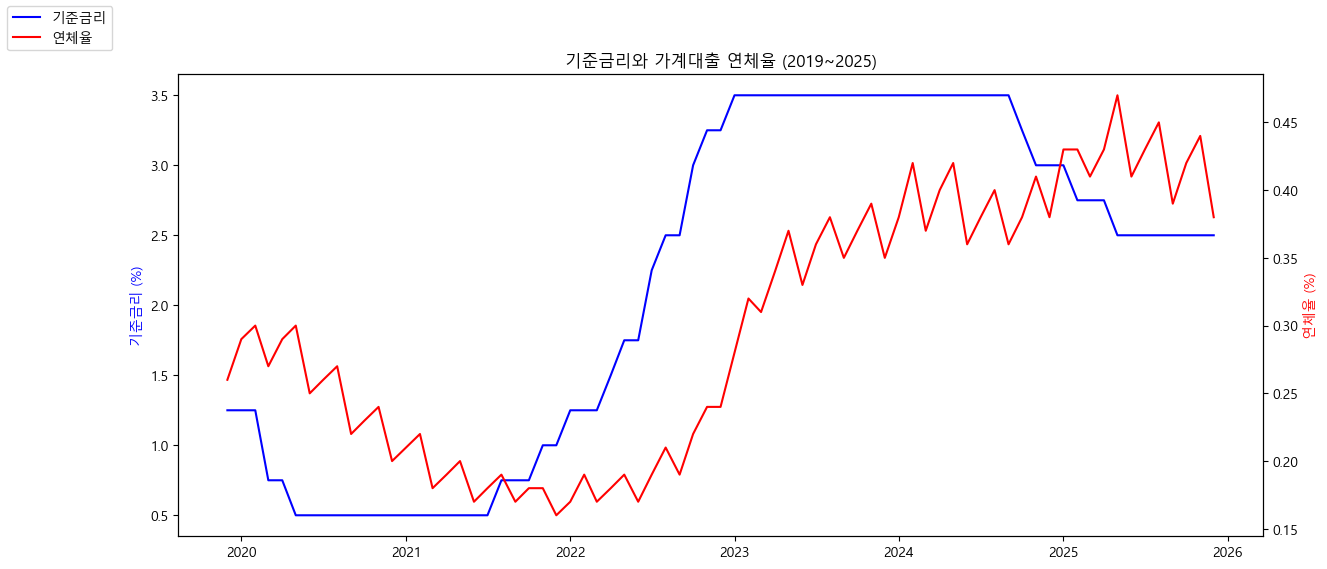

In [6]:
# =====================
# 기준금리 vs 연체율 기본 시각화
# twinx():값의 범위가 다른 두 변수를 비교하기 위해 y축을 두 개 만드는 함수
# =====================
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['날짜'], df['기준금리'], color='blue', label='기준금리')
ax1.set_ylabel('기준금리 (%)', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['연체율'], color='red', label='연체율')
ax2.set_ylabel('연체율 (%)', color='red')

plt.title('기준금리와 가계대출 연체율 (2019~2025)')
fig.legend(loc='upper left')
plt.show()

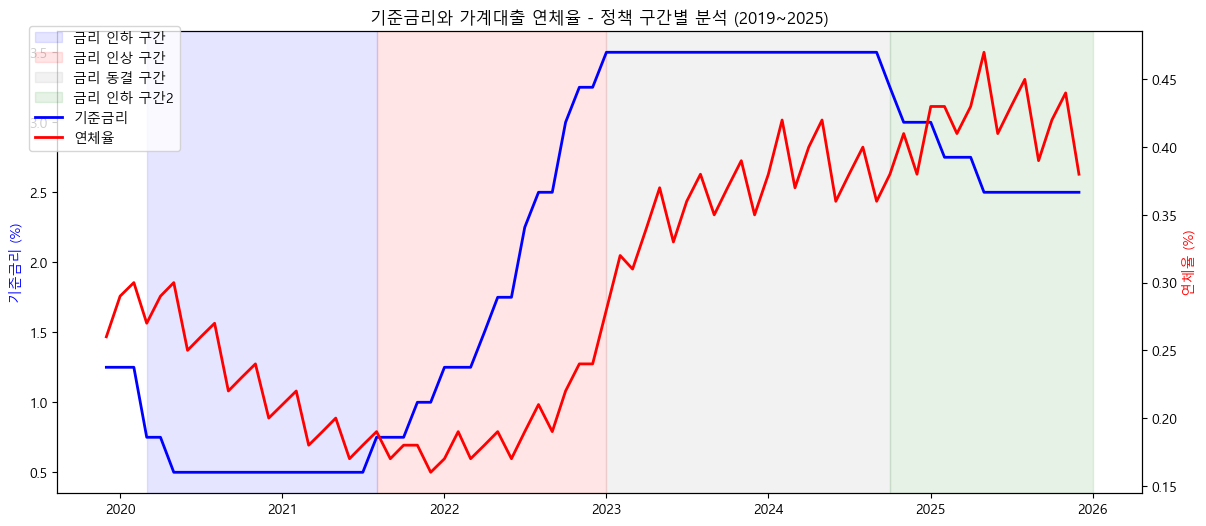

In [7]:
# =====================
# 금리 구간별 시각화
# axvspan(): 특정 기간을 색으로 칠해주는 함수
# 금리 인하/인상/동결 구간을 색으로 구분해서 패턴을 시각적으로 확인
# =====================
fig, ax1 = plt.subplots(figsize=(14, 6))

# 구간 색칠
ax1.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-08'), alpha=0.1, color='blue', label='금리 인하 구간')
ax1.axvspan(pd.Timestamp('2021-08'), pd.Timestamp('2023-01'), alpha=0.1, color='red', label='금리 인상 구간')
ax1.axvspan(pd.Timestamp('2023-01'), pd.Timestamp('2024-10'), alpha=0.1, color='gray', label='금리 동결 구간')
ax1.axvspan(pd.Timestamp('2024-10'), pd.Timestamp('2026-01'), alpha=0.1, color='green', label='금리 인하 구간2')

# 기준금리
ax1.plot(df['날짜'], df['기준금리'], color='blue', linewidth=2, label='기준금리')
ax1.set_ylabel('기준금리 (%)', color='blue')

# 연체율
ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['연체율'], color='red', linewidth=2, label='연체율')
ax2.set_ylabel('연체율 (%)', color='red')

plt.title('기준금리와 가계대출 연체율 - 정책 구간별 분석 (2019~2025)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## 3. 1차 분석 - 원시계열 시차 상관관계

기준금리와 연체율의 원시계열을 가지고, 0~12개월 시차를 적용했을 때 상관관계가 어떻게 달라지는지 확인한다.

In [8]:
# =====================
# 시차 상관관계 분석 (원시계열)
# 0~12개월 시차를 바꿔가며 기준금리와 연체율의 상관관계를 계산
# corr(): 두 변수의 상관관계를 계산하는 함수 (-1 ~ 1)
# shift(): 데이터를 시간축으로 밀어주는 함수
# =====================
correlations = {}

for lag in range(0, 13):
    correlations[lag] = df['기준금리'].corr(df['연체율'].shift(-lag))

for lag, corr in correlations.items():
    print(f'시차 {lag:2d}개월 후 상관관계: {corr:.6f}')

시차  0개월 후 상관관계: 0.698311
시차  1개월 후 상관관계: 0.742515
시차  2개월 후 상관관계: 0.784424
시차  3개월 후 상관관계: 0.829520
시차  4개월 후 상관관계: 0.863711
시차  5개월 후 상관관계: 0.891135
시차  6개월 후 상관관계: 0.921409
시차  7개월 후 상관관계: 0.938491
시차  8개월 후 상관관계: 0.947962
시차  9개월 후 상관관계: 0.958155
시차 10개월 후 상관관계: 0.957505
시차 11개월 후 상관관계: 0.951550
시차 12개월 후 상관관계: 0.947324


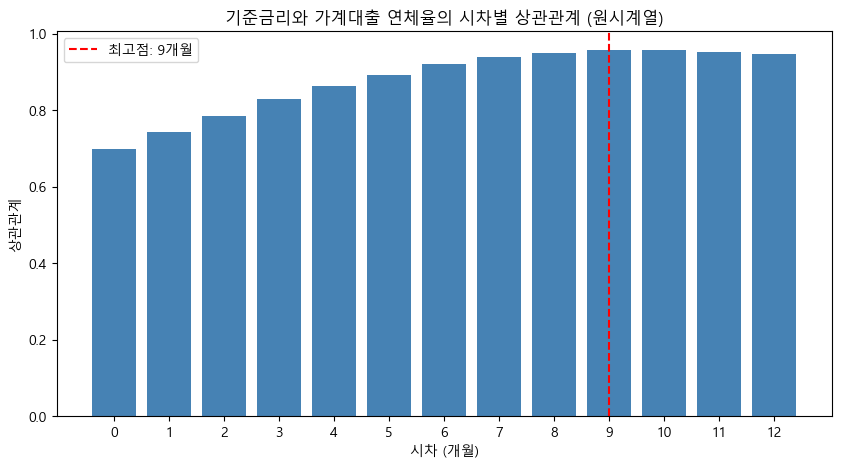

In [9]:
# =====================
# 시차별 상관관계 시각화
# 어느 시차에서 상관관계가 가장 높은지 막대 그래프로 표현
# axvline(): 특정 지점에 세로 기준선을 그어주는 함수
# =====================
corr_series = pd.Series(correlations)

plt.figure(figsize=(10, 5))
plt.bar(corr_series.index, corr_series.values, color='steelblue')
plt.axvline(x=corr_series.idxmax(), color='red', linestyle='--', label=f'최고점: {corr_series.idxmax()}개월')
plt.xlabel('시차 (개월)')
plt.ylabel('상관관계')
plt.title('기준금리와 가계대출 연체율의 시차별 상관관계 (원시계열)')
plt.xticks(range(0, 13))
plt.legend()
plt.show()

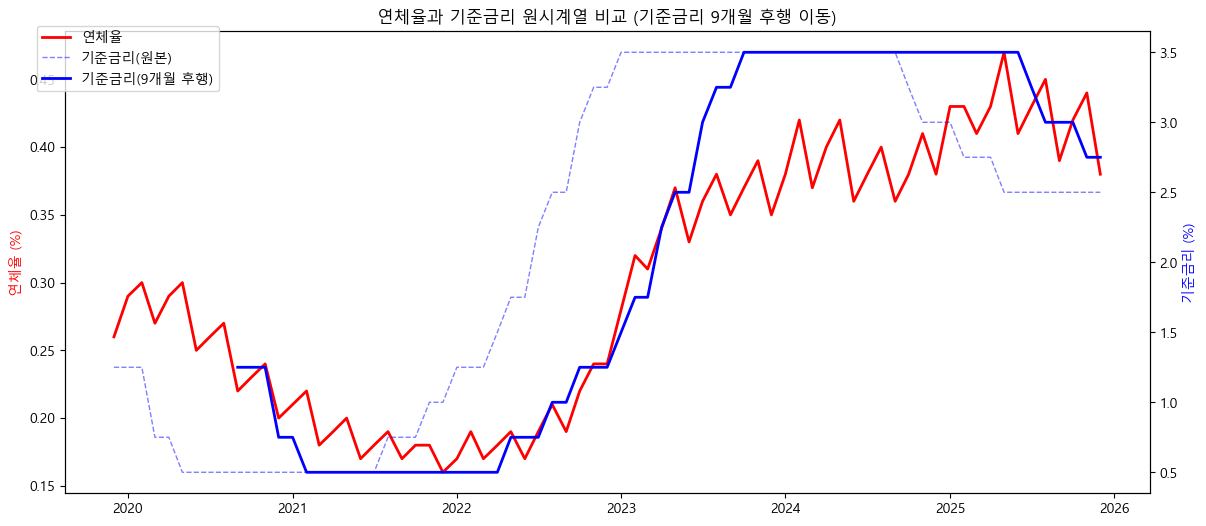

In [12]:
# =====================
# 9개월 시차 적용 시각화
# 기준금리 원시계열을 시간축에서 9개월 뒤로 이동
# 과거 기준금리와 9개월 후 연체율의 움직임을 시각적으로 비교
# =====================
df['기준금리_9개월시차'] = df['기준금리'].shift(9)

fig, ax1 = plt.subplots(figsize=(14, 6))


# 연체율
ax1.plot(df['날짜'], df['연체율'], color='red', linewidth=2, label='연체율')
ax1.set_ylabel('연체율 (%)', color='red')

# 기준금리 (원본)
ax2 = ax1.twinx()
ax2.plot(df['날짜'], df['기준금리'], color='blue', linewidth=1, linestyle='--', alpha=0.5, label='기준금리(원본)')

# 기준금리 (9개월 시차 적용)
ax2.plot(df['날짜'], df['기준금리_9개월시차'], color='blue', linewidth=2, label='기준금리(9개월 후행)')
ax2.set_ylabel('기준금리 (%)', color='blue')

plt.title('연체율과 기준금리 원시계열 비교 (기준금리 9개월 후행 이동)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## 4. 구간별 평균 연체율 비교

구간
①금리인하전      0.283333
②금리인하구간     0.228235
③금리인상구간     0.190588
④금리동결구간     0.363810
⑤금리인하구간2    0.417333
Name: 연체율, dtype: float64


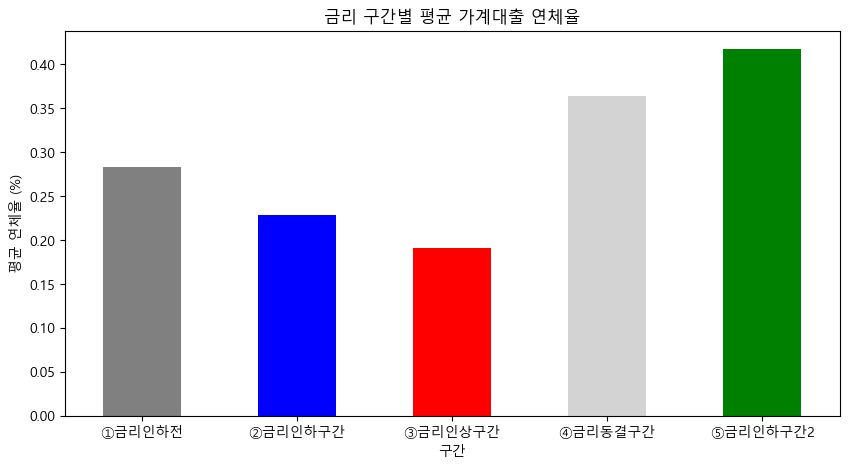

In [13]:
# =====================
# 구간별 평균 연체율 비교
# groupby(): 그룹별로 묶어서 평균을 계산하는 함수
# 금리 구간별 연체율 수준을 기술적으로 비교
# 구간별 평균은 시차 효과나 인과관계를 직접 검증하는 결과가 아님
# =====================

# 구간 라벨 붙이기
def get_period(date):
    if date < pd.Timestamp('2020-03'):
        return '①금리인하전'
    elif date < pd.Timestamp('2021-08'):
        return '②금리인하구간'
    elif date < pd.Timestamp('2023-01'):
        return '③금리인상구간'
    elif date < pd.Timestamp('2024-10'):
        return '④금리동결구간'
    else:
        return '⑤금리인하구간2'

df['구간'] = df['날짜'].apply(get_period)

# 구간별 평균 연체율 계산
avg_by_period = df.groupby('구간')['연체율'].mean()
print(avg_by_period)

# 막대 그래프
plt.figure(figsize=(10, 5))
avg_by_period.plot(kind='bar', color=['gray', 'blue', 'red', 'lightgray', 'green'])
plt.title('금리 구간별 평균 가계대출 연체율')
plt.xlabel('구간')
plt.ylabel('평균 연체율 (%)')
plt.xticks(rotation=0)
plt.show()

## 5. 차분 & ADF 정상성 검정

1차 분석에서 9개월 시차의 상관계수가 0.958로 매우 높게 나타났다. 그러나 원시계열에 공통 추세가 존재하면 실제 관계보다 상관계수가 높게 나타나는 **가성 상관관계(spurious correlation)** 가 발생할 수 있으므로 정상성 확인이 필요하다.

이를 위해 기준금리와 연체율의 **1차 차분값(월별 변화량)** 을 계산하고, ADF 검정을 통해 원시계열과 차분 시계열의 정상성을 확인한다.

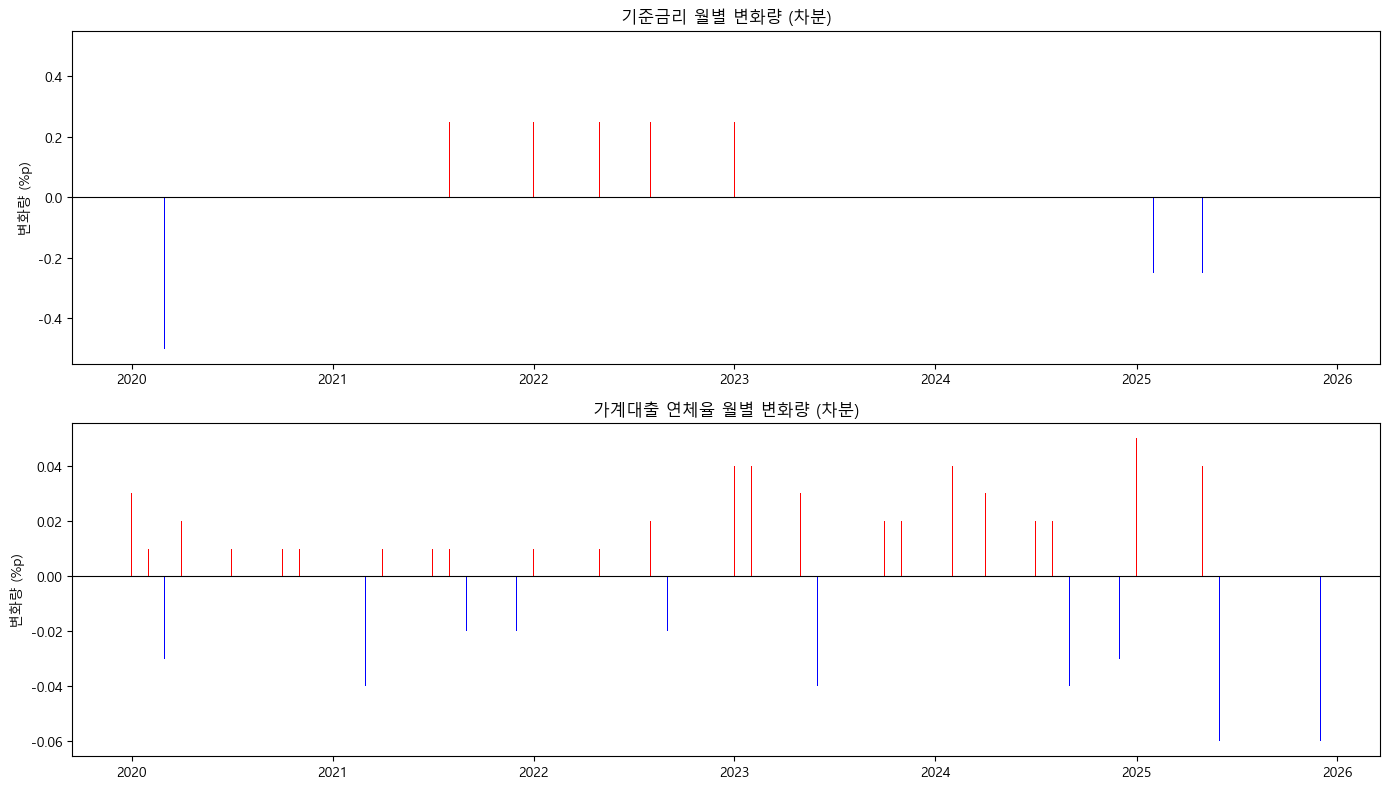

In [14]:
# =====================
# 차분 계산 & 시각화
# diff(): 이번 값 - 이전 값을 계산하는 함수 (변화량)
# 금리/연체율이 '언제 얼마나' 변했는지를 보여줌
# =====================
df['기준금리_차분'] = df['기준금리'].diff()
df['연체율_차분'] = df['연체율'].diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# 기준금리 차분
ax1.bar(df['날짜'], df['기준금리_차분'], color=df['기준금리_차분'].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')))
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_title('기준금리 월별 변화량 (차분)')
ax1.set_ylabel('변화량 (%p)')

# 연체율 차분
ax2.bar(df['날짜'], df['연체율_차분'], color=df['연체율_차분'].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')))
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('가계대출 연체율 월별 변화량 (차분)')
ax2.set_ylabel('변화량 (%p)')

plt.tight_layout()
plt.show()

In [15]:
# =====================
# ADF 정상성 검정
# ADF 검정: 시계열이 안정적(정상)인지 통계적으로 확인
# p-value < 0.05 : 정상 시계열로 판단
# p-value >= 0.05 : 정상성을 확인하지 못함
# =====================
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'[{name}]')
    print(f'ADF 통계량: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] < 0.05 :
        print('결론 : 5% 유의수준에서 정상 시계열로 판단')
    else :
        print('결론 : 5% 유의수준에서 정상성을 확인하지 못함')
    print()

adf_test(df['기준금리'], '기준금리 원시계열')
adf_test(df['연체율'], '연체율 원시계열')
adf_test(df['기준금리_차분'], '기준금리 차분')
adf_test(df['연체율_차분'], '연체율 차분')

[기준금리 원시계열]
ADF 통계량: -2.2884
p-value: 0.1757
결론 : 5% 유의수준에서 정상성을 확인하지 못함

[연체율 원시계열]
ADF 통계량: -1.1620
p-value: 0.6897
결론 : 5% 유의수준에서 정상성을 확인하지 못함

[기준금리 차분]
ADF 통계량: -2.3868
p-value: 0.1455
결론 : 5% 유의수준에서 정상성을 확인하지 못함

[연체율 차분]
ADF 통계량: -2.6375
p-value: 0.0855
결론 : 5% 유의수준에서 정상성을 확인하지 못함



**검정 결과**: ADF 검정 결과 원시계열은 5% 유의수준에서 정상성을 확인하지 못했으며, 1차 차분 후에도 정상성이 명확하게 확인되지 않았다. 이는 분석 기간 중 금리 정책 국면 전환과 같은 구조적 변화가 존재했기 때문일 수 있다.

따라서 원시계열에서 나타난 높은 상관관계는 공통적인 추세의 영향을 받았을 가능성이 있다. 이러한 추세 영향을 완화하기 위해 1차 차분 데이터를 사용하여 CCF를 다시 계산하고, 단기 변화량 사이의 시차 관계를 탐색한다.

## 6. 2차 분석 - CCF (차분 데이터, statsmodels)

공통 추세의 영향을 완화하기 위해 1차 차분 데이터로 CCF를 계산한다. `ccf(연체율 차분, 기준금리 차분)`의 양의 시차는 과거 기준금리 변화와 이후 연체율 변화의 상관관계를 의미한다. 그래프의 회색 점선은 표본 수를 이용해 계산한 근사적인 95% 신뢰한계이다.

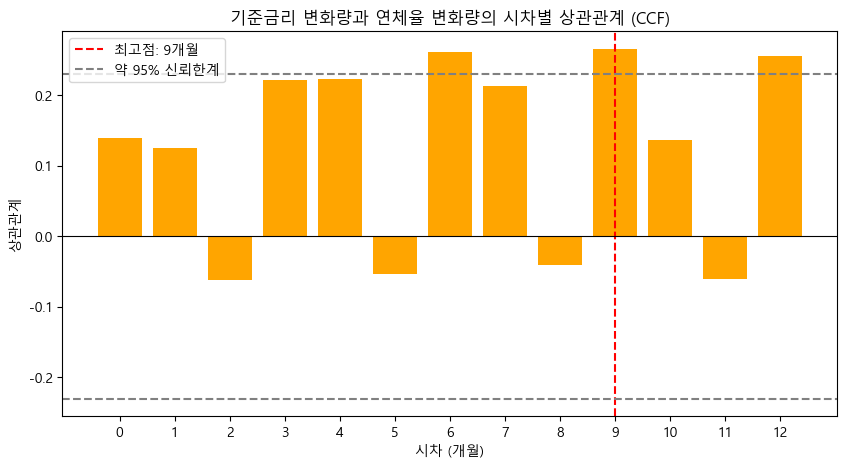

시차  0개월 후 상관관계: 0.140
시차  1개월 후 상관관계: 0.125
시차  2개월 후 상관관계: -0.062
시차  3개월 후 상관관계: 0.222
시차  4개월 후 상관관계: 0.223
시차  5개월 후 상관관계: -0.054
시차  6개월 후 상관관계: 0.262
시차  7개월 후 상관관계: 0.213
시차  8개월 후 상관관계: -0.041
시차  9개월 후 상관관계: 0.266
시차 10개월 후 상관관계: 0.136
시차 11개월 후 상관관계: -0.061
시차 12개월 후 상관관계: 0.255


In [16]:
# =====================
# CCF (교차상관) 분석 - 차분 데이터 사용
# ccf(): 두 시계열 간 시차별 상관관계를 계산하는 표준 함수
# 공통 추세의 영향을 완화한 차분 데이터를 이용해 시차 관계를 확인
# =====================
from statsmodels.tsa.stattools import ccf

x = df['기준금리_차분'].dropna()
y = df['연체율_차분'].dropna()

ccf_values = ccf(y, x, adjusted=False)

# 0~12개월 시차만 확인
ccf_12 = ccf_values[:13]

plt.figure(figsize=(10, 5))
plt.bar(range(13), ccf_12, color='orange')
plt.axvline(x=ccf_12.argmax(), color='red', linestyle='--', label=f'최고점: {ccf_12.argmax()}개월')
plt.xlabel('시차 (개월)')
plt.ylabel('상관관계')
plt.title('기준금리 변화량과 연체율 변화량의 시차별 상관관계 (CCF)')
plt.xticks(range(0, 13))
plt.axhline(y=0, color='black', linewidth=0.8)

n = df[['기준금리_차분', '연체율_차분']].dropna().shape[0]
conf = 1.96 / np.sqrt(n)

plt.axhline(conf, color='gray', linestyle='--', label='약 95% 신뢰한계')
plt.axhline(-conf, color='gray', linestyle='--')

plt.legend()
plt.show()

for lag, val in enumerate(ccf_12):
    print(f'시차 {lag:2d}개월 후 상관관계: {val:.3f}')

## 결론

### 분석 과정 요약
| 단계 | 방법 | 결과 |
|------|------|------|
| 1차 분석 | 원시계열 시차 상관관계 | 9개월 시차에서 0.958 (최고점) |
| 정상성 검정 | ADF 검정 | 원본/차분 모두 5% 유의수준에서 정상성 미확인 |
| 2차 분석 | 차분 데이터 CCF (statsmodels) | 9개월 시차에서 최고 약 0.27, 관계는 약함 |

1차 분석에서 9개월 시차의 상관계수가 0.958로 매우 높게 나타났으나, ADF 검정 결과 원시계열은 5% 유의수준에서 정상성을 확인하지 못했다. 따라서 원시계열의 높은 상관관계는 두 시계열의 공통 추세에 의해 과대평가되었을 가능성이 있다.

공통 추세의 영향을 완화하기 위해 1차 차분 데이터로 CCF를 분석한 결과, 9개월 시차에서 가장 높은 상관계수인 약 0.27이 나타났다. 다만 상관관계가 강하지 않고 6개월과 12개월에서도 비교적 높은 값이 관찰되어, 9개월의 뚜렷하고 독립적인 시차 효과가 확인되었다고 단정하기는 어렵다. 또한 분석 기간이 73개월로 짧아 결과를 탐색적으로 해석할 필요가 있다.

### 최종 해석
원시계열 분석에서는 9개월 시차에서 가장 높은 상관관계가 관찰되었다. 차분 CCF 분석에서도 9개월 시차의 상관계수가 가장 높았지만, 그 크기는 약 0.27로 강한 관계는 아니었다. 따라서 9개월을 확정적인 반응 시점으로 단정하기보다는 추가 검증이 필요한 탐색적 후보 시차로 해석해야 한다. 향후 더 긴 기간의 데이터와 추가 변수를 활용한 회귀분석 또는 시계열 모형을 통해 검증할 필요가 있다.

### 분석의 한계
- 데이터 기간(73개월)이 짧아 차분 후 통계적 검정력이 낮음
- 분석 기간 내 금리 정책 국면이 여러 차례 전환되어 구조적 변화 존재
- 상관관계 기반 분석으로 인과관계 확인 불가

### 시사점
기준금리 변화와 가계대출 연체율 사이에서 약 9개월의 시차 가능성이 관찰되었다. 다만 차분 CCF의 상관관계가 강하지 않으므로, 이를 확정적인 반응 시점으로 해석하기보다 금융기관의 연체율 모니터링을 위한 탐색적 참고 지표로 활용할 수 있다. 향후 더 긴 기간의 데이터와 추가 변수를 활용한 검증이 필요하다.